# 股票技术指标计算与可视化

**股票标的**：三一重工 (600031.SH) 、平安集团 (000001.SZ)

**计算指标**：RSI、MACD、布林带（Bollinger Bands）、KDJ

---

## 1. 导入依赖库 & 读取数据

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（通用兼容方案）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 读取行情数据
df_sany = pd.read_csv('三一重工行情数据.csv')
df_pingan = pd.read_csv('平安集团行情数据.csv')

# 统一日期格式
df_sany['trade_date'] = pd.to_datetime(df_sany['trade_date'], format='%Y%m%d')
df_pingan['trade_date'] = pd.to_datetime(df_pingan['trade_date'], format='%Y%m%d')

# 按日期排序
df_sany = df_sany.sort_values('trade_date').reset_index(drop=True)
df_pingan = df_pingan.sort_values('trade_date').reset_index(drop=True)

print('三一重工数据:', df_sany.shape)
print('平安集团数据:', df_pingan.shape)
df_sany.head(3)

三一重工数据: (129, 11)
平安集团数据: (372, 11)


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,600031.SH,2025-01-02,16.48,16.48,15.69,15.77,16.48,-0.71,-4.3083,853894.28,1368558.133
1,600031.SH,2025-01-03,15.85,16.00,15.55,15.60,15.77,-0.17,-1.0780,534033.71,842151.570
2,600031.SH,2025-01-06,15.60,15.71,15.42,15.58,15.60,-0.02,-0.1282,454873.82,707452.833


## 2. RSI（相对强弱指数）计算

公式：
- $RSI = 100 - \frac{100}{1 + RS}$，其中 $RS = \frac{\text{平均上涨幅度}}{\text{平均下跌幅度}}$
- 常用周期：14日

In [12]:
def calc_rsi(close, period=14):
    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = (-delta).where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# 计算RSI
df_sany['RSI_14'] = calc_rsi(df_sany['close'], period=14)
df_pingan['RSI_14'] = calc_rsi(df_pingan['close'], period=14)

print('RSI计算完成 — 示例值：')
print(df_sany[['trade_date','close','RSI_14']].tail(5))

RSI计算完成 — 示例值：
    trade_date  close     RSI_14
124 2025-07-10  18.92  61.978014
125 2025-07-11  18.83  59.763535
126 2025-07-14  18.74  57.549128
127 2025-07-15  18.90  60.361063
128 2025-07-16  18.71  55.647167


## 3. MACD（指数平滑异同移动平均线）计算

公式：
- $DIF = EMA_{12}(close) - EMA_{26}(close)$
- $DEA = EMA_{9}(DIF)$
- $MACD_{hist} = 2 \times (DIF - DEA)$

In [13]:
def calc_macd(close, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    dif = ema_fast - ema_slow
    dea = dif.ewm(span=signal, adjust=False).mean()
    hist = 2 * (dif - dea)
    return dif, dea, hist

# 计算MACD
df_sany['MACD_DIF'], df_sany['MACD_DEA'], df_sany['MACD_HIST'] = calc_macd(df_sany['close'])
df_pingan['MACD_DIF'], df_pingan['MACD_DEA'], df_pingan['MACD_HIST'] = calc_macd(df_pingan['close'])

print('MACD计算完成 — 示例值：')
print(df_sany[['trade_date','close','MACD_DIF','MACD_DEA','MACD_HIST']].tail(5))

MACD计算完成 — 示例值：
    trade_date  close  MACD_DIF  MACD_DEA  MACD_HIST
124 2025-07-10  18.92  0.108013 -0.065920   0.347865
125 2025-07-11  18.83  0.130860 -0.026564   0.314847
126 2025-07-14  18.74  0.140089  0.006767   0.266645
127 2025-07-15  18.90  0.158487  0.037111   0.242753
128 2025-07-16  18.71  0.155939  0.060876   0.190125


## 4. 布林带（Bollinger Bands）计算

公式：
- 中轨 = $SMA_{20}(close)$
- 上轨 = 中轨 + $2 \times \sigma_{20}(close)$
- 下轨 = 中轨 - $2 \times \sigma_{20}(close)$

In [14]:
def calc_bollinger(close, period=20, num_std=2):
    middle = close.rolling(window=period).mean()
    std = close.rolling(window=period).std()
    upper = middle + num_std * std
    lower = middle - num_std * std
    return middle, upper, lower

# 计算布林带
df_sany['BB_MID'], df_sany['BB_UPPER'], df_sany['BB_LOWER'] = calc_bollinger(df_sany['close'])
df_pingan['BB_MID'], df_pingan['BB_UPPER'], df_pingan['BB_LOWER'] = calc_bollinger(df_pingan['close'])

print('布林带计算完成 — 示例值：')
print(df_sany[['trade_date','close','BB_MID','BB_UPPER','BB_LOWER']].tail(5))

布林带计算完成 — 示例值：
    trade_date  close   BB_MID   BB_UPPER   BB_LOWER
124 2025-07-10  18.92  18.0785  19.024233  17.132767
125 2025-07-11  18.83  18.1305  19.122669  17.138331
126 2025-07-14  18.74  18.1770  19.192814  17.161186
127 2025-07-15  18.90  18.2205  19.283237  17.157763
128 2025-07-16  18.71  18.2670  19.329967  17.204033


## 5. KDJ（随机指标）计算

公式：
- $RSV_t = \frac{Close_t - LLV(Low, 9)}{HHV(High, 9) - LLV(Low, 9)} \times 100$
- $K_t = \frac{2}{3} K_{t-1} + \frac{1}{3} RSV_t$
- $D_t = \frac{2}{3} D_{t-1} + \frac{1}{3} K_t$
- $J_t = 3K_t - 2D_t$

- K、D 初始值通常设为 50
- K > 80 超买，K < 20 超卖；K 上穿 D 为金叉，下穿为死叉

In [15]:
def calc_kdj(df, n=9, m1=3, m2=3):
    low_min = df['low'].rolling(window=n, min_periods=n).min()
    high_max = df['high'].rolling(window=n, min_periods=n).max()
    rsv = (df['close'] - low_min) / (high_max - low_min) * 100

    k = pd.Series(index=df.index, dtype=float)
    d = pd.Series(index=df.index, dtype=float)

    # 第一个有效位置初始化 K=D=50
    first_valid = rsv.first_valid_index()
    if first_valid is not None:
        k.iloc[df.index.get_loc(first_valid)] = 50.0
        d.iloc[df.index.get_loc(first_valid)] = 50.0

    for i in range(df.index.get_loc(first_valid) + 1, len(df)):
        k.iloc[i] = (2/3) * k.iloc[i-1] + (1/3) * rsv.iloc[i]
        d.iloc[i] = (2/3) * d.iloc[i-1] + (1/3) * k.iloc[i]

    j = 3 * k - 2 * d
    return k, d, j

# 计算KDJ
df_sany['KDJ_K'], df_sany['KDJ_D'], df_sany['KDJ_J'] = calc_kdj(df_sany)
df_pingan['KDJ_K'], df_pingan['KDJ_D'], df_pingan['KDJ_J'] = calc_kdj(df_pingan)

print('KDJ计算完成 — 示例值：')
print(df_sany[['trade_date','close','KDJ_K','KDJ_D','KDJ_J']].tail(5))

KDJ计算完成 — 示例值：
    trade_date  close      KDJ_K      KDJ_D      KDJ_J
124 2025-07-10  18.92  85.734297  82.866137  91.470616
125 2025-07-11  18.83  81.491576  82.407950  79.658828
126 2025-07-14  18.74  76.189189  80.335030  67.897508
127 2025-07-15  18.90  74.016837  78.228965  65.592579
128 2025-07-16  18.71  67.377345  74.611758  52.908517


## 6. 三一重工 — 技术指标可视化

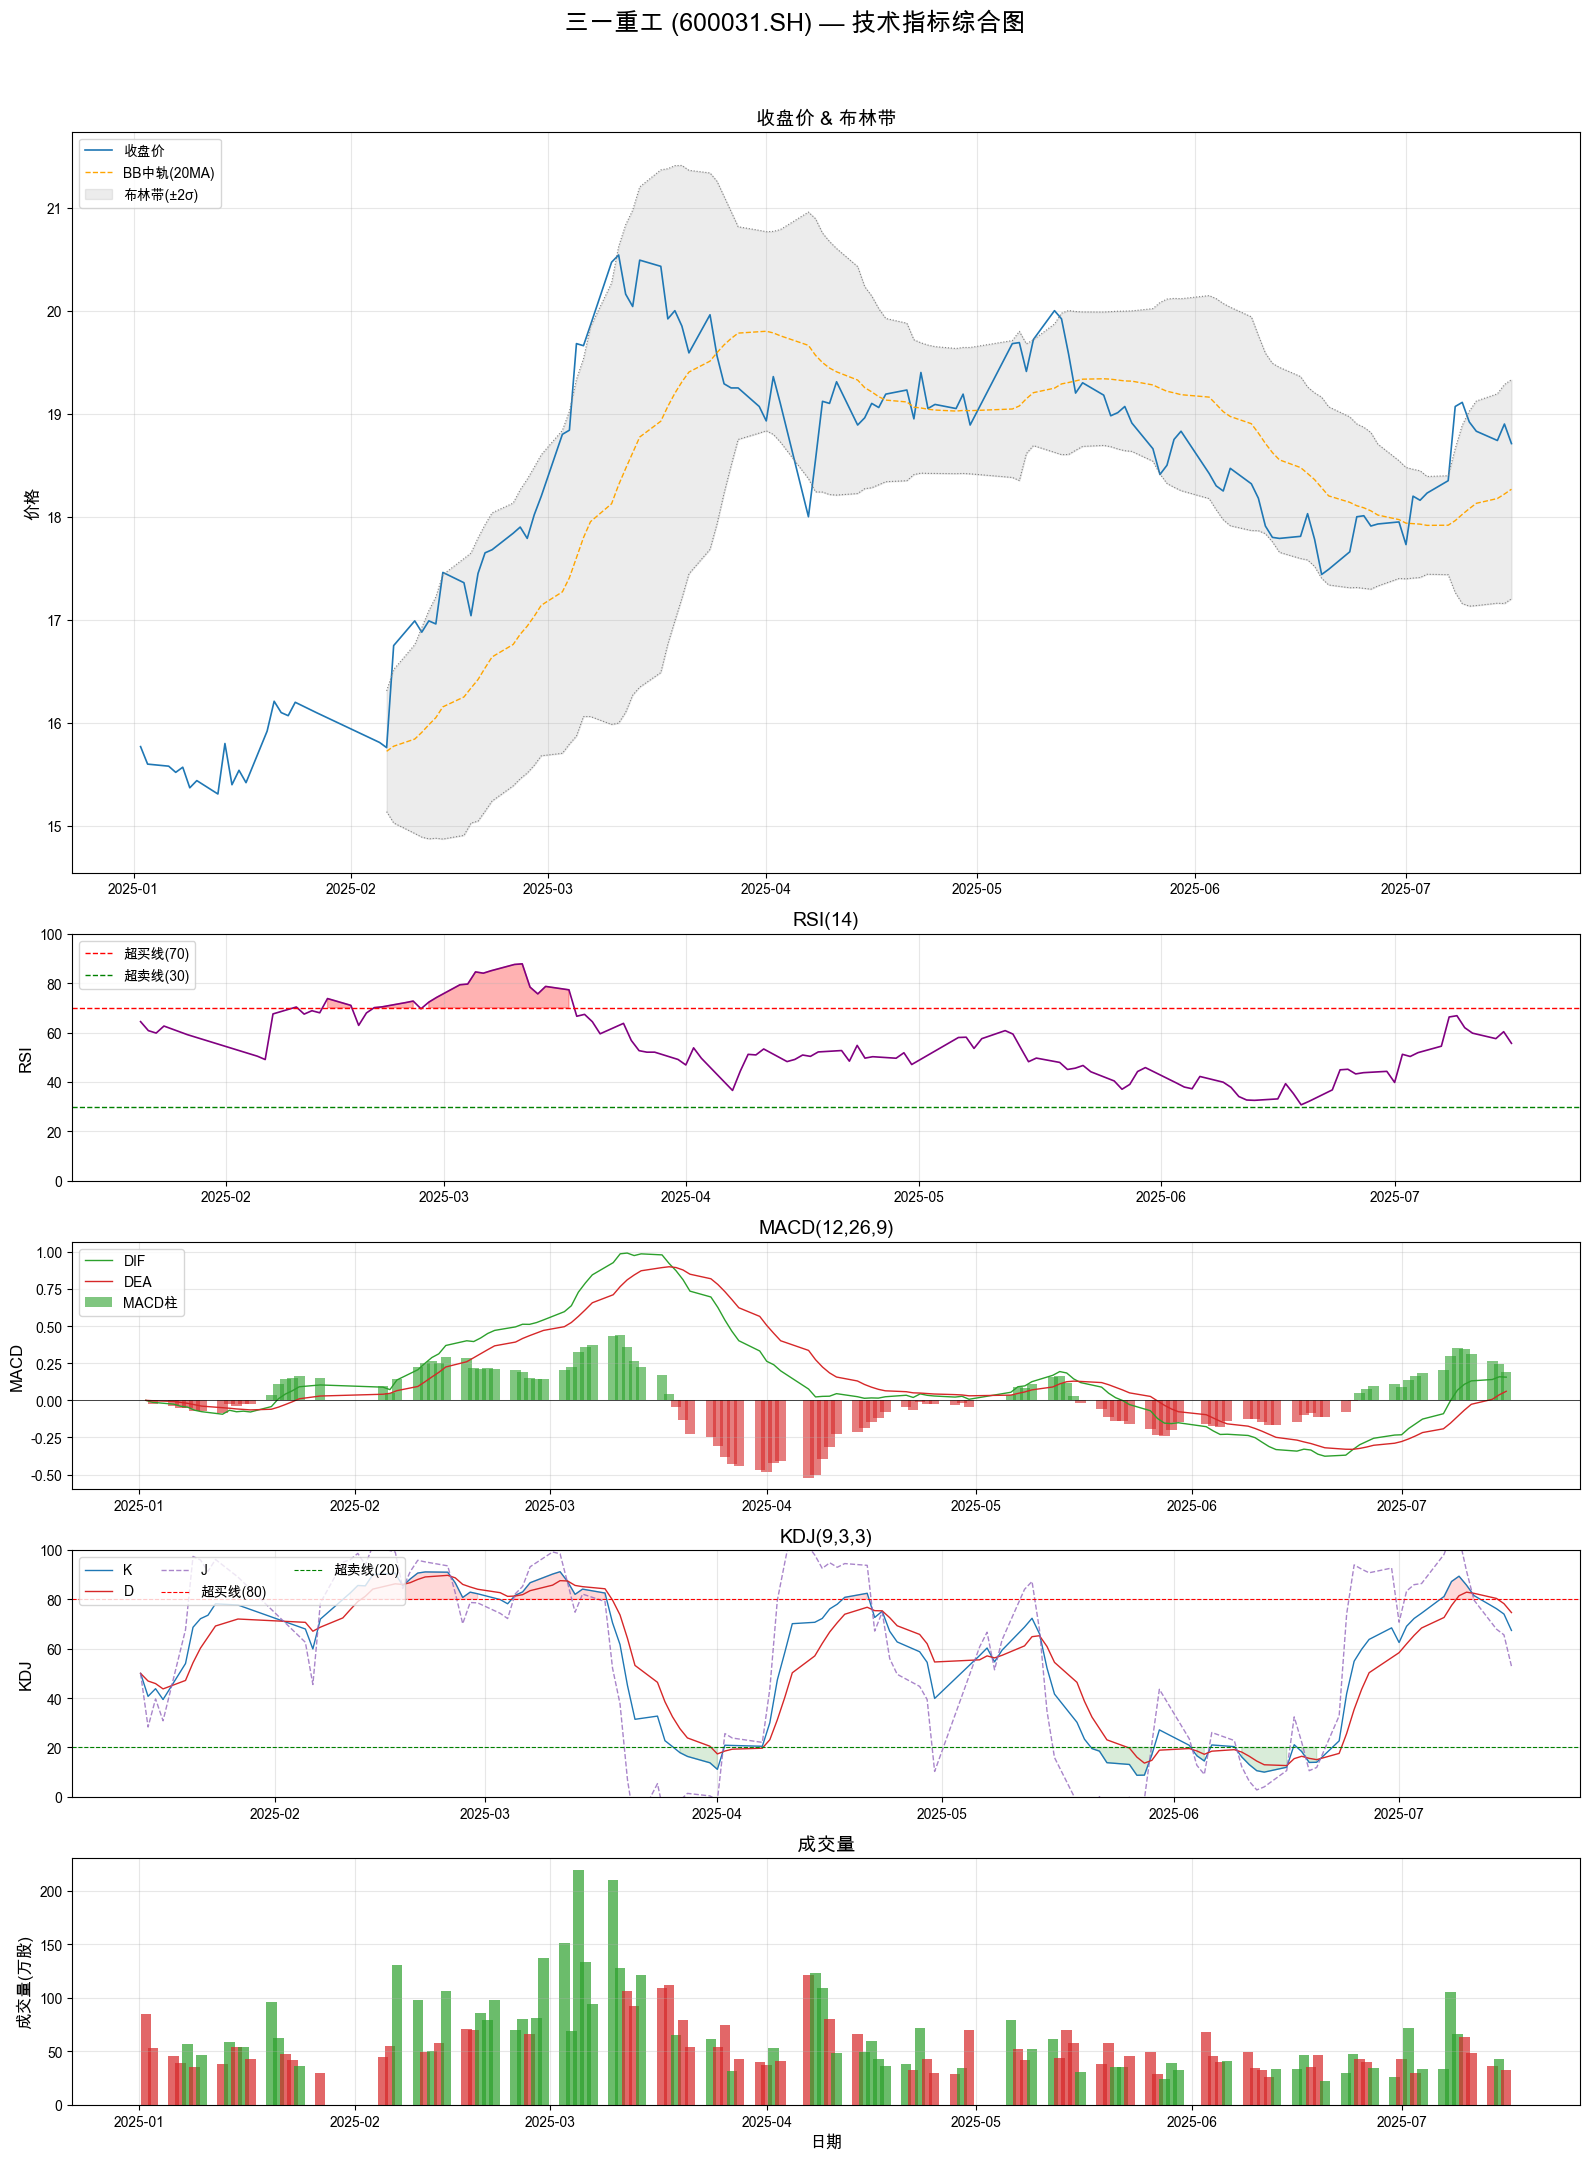

In [16]:
def plot_stock_indicators(df, title):
    fig, axes = plt.subplots(5, 1, figsize=(16, 22), gridspec_kw={'height_ratios': [3, 1, 1, 1, 1]})
    fig.suptitle(title, fontsize=18, fontweight='bold', y=0.98)

    dates = df['trade_date']
    close = df['close']

    # ── 图1: 收盘价 + 布林带 ──
    ax1 = axes[0]
    ax1.plot(dates, close, label='收盘价', color='#1f77b4', linewidth=1.2)
    ax1.plot(dates, df['BB_MID'], label='BB中轨(20MA)', color='orange', linewidth=1, linestyle='--')
    ax1.fill_between(dates, df['BB_UPPER'], df['BB_LOWER'], alpha=0.15, color='gray', label='布林带(±2σ)')
    ax1.plot(dates, df['BB_UPPER'], color='gray', linewidth=0.8, linestyle=':')
    ax1.plot(dates, df['BB_LOWER'], color='gray', linewidth=0.8, linestyle=':')
    ax1.set_ylabel('价格', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_title('收盘价 & 布林带', fontsize=14)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # ── 图2: RSI ──
    ax2 = axes[1]
    ax2.plot(dates, df['RSI_14'], color='purple', linewidth=1.2)
    ax2.axhline(70, color='red', linestyle='--', linewidth=1, label='超买线(70)')
    ax2.axhline(30, color='green', linestyle='--', linewidth=1, label='超卖线(30)')
    ax2.fill_between(dates, df['RSI_14'], 70, where=(df['RSI_14'] > 70), color='red', alpha=0.3)
    ax2.fill_between(dates, df['RSI_14'], 30, where=(df['RSI_14'] < 30), color='green', alpha=0.3)
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_title('RSI(14)', fontsize=14)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # ── 图3: MACD ──
    ax3 = axes[2]
    ax3.plot(dates, df['MACD_DIF'], label='DIF', color='#2ca02c', linewidth=1)
    ax3.plot(dates, df['MACD_DEA'], label='DEA', color='#d62728', linewidth=1)
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in df['MACD_HIST']]
    ax3.bar(dates, df['MACD_HIST'], color=colors, width=1.5, alpha=0.6, label='MACD柱')
    ax3.axhline(0, color='black', linewidth=0.5)
    ax3.set_ylabel('MACD', fontsize=12)
    ax3.legend(loc='upper left', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_title('MACD(12,26,9)', fontsize=14)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # ── 图4: KDJ ──
    ax4 = axes[3]
    ax4.plot(dates, df['KDJ_K'], label='K', color='#1f77b4', linewidth=1)
    ax4.plot(dates, df['KDJ_D'], label='D', color='#d62728', linewidth=1)
    ax4.plot(dates, df['KDJ_J'], label='J', color='#9467bd', linewidth=1, linestyle='--', alpha=0.8)
    ax4.axhline(80, color='red', linestyle='--', linewidth=0.8, label='超买线(80)')
    ax4.axhline(20, color='green', linestyle='--', linewidth=0.8, label='超卖线(20)')
    ax4.fill_between(dates, df['KDJ_K'], 80, where=(df['KDJ_K'] > 80), color='red', alpha=0.15)
    ax4.fill_between(dates, df['KDJ_K'], 20, where=(df['KDJ_K'] < 20), color='green', alpha=0.15)
    ax4.set_ylabel('KDJ', fontsize=12)
    ax4.set_ylim(0, 100)
    ax4.legend(loc='upper left', fontsize=10, ncol=3)
    ax4.grid(True, alpha=0.3)
    ax4.set_title('KDJ(9,3,3)', fontsize=14)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # ── 图5: 成交量 ──
    ax5 = axes[4]
    colors_vol = ['#d62728' if c < o else '#2ca02c' for c, o in zip(df['close'], df['open'])]
    ax5.bar(dates, df['vol']/10000, color=colors_vol, width=1.5, alpha=0.7)
    ax5.set_ylabel('成交量(万股)', fontsize=12)
    ax5.set_xlabel('日期', fontsize=12)
    ax5.grid(True, alpha=0.3)
    ax5.set_title('成交量', fontsize=14)
    ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# 绘制三一重工
plot_stock_indicators(df_sany, '三一重工 (600031.SH) — 技术指标综合图')

## 7. 平安集团 — 技术指标可视化

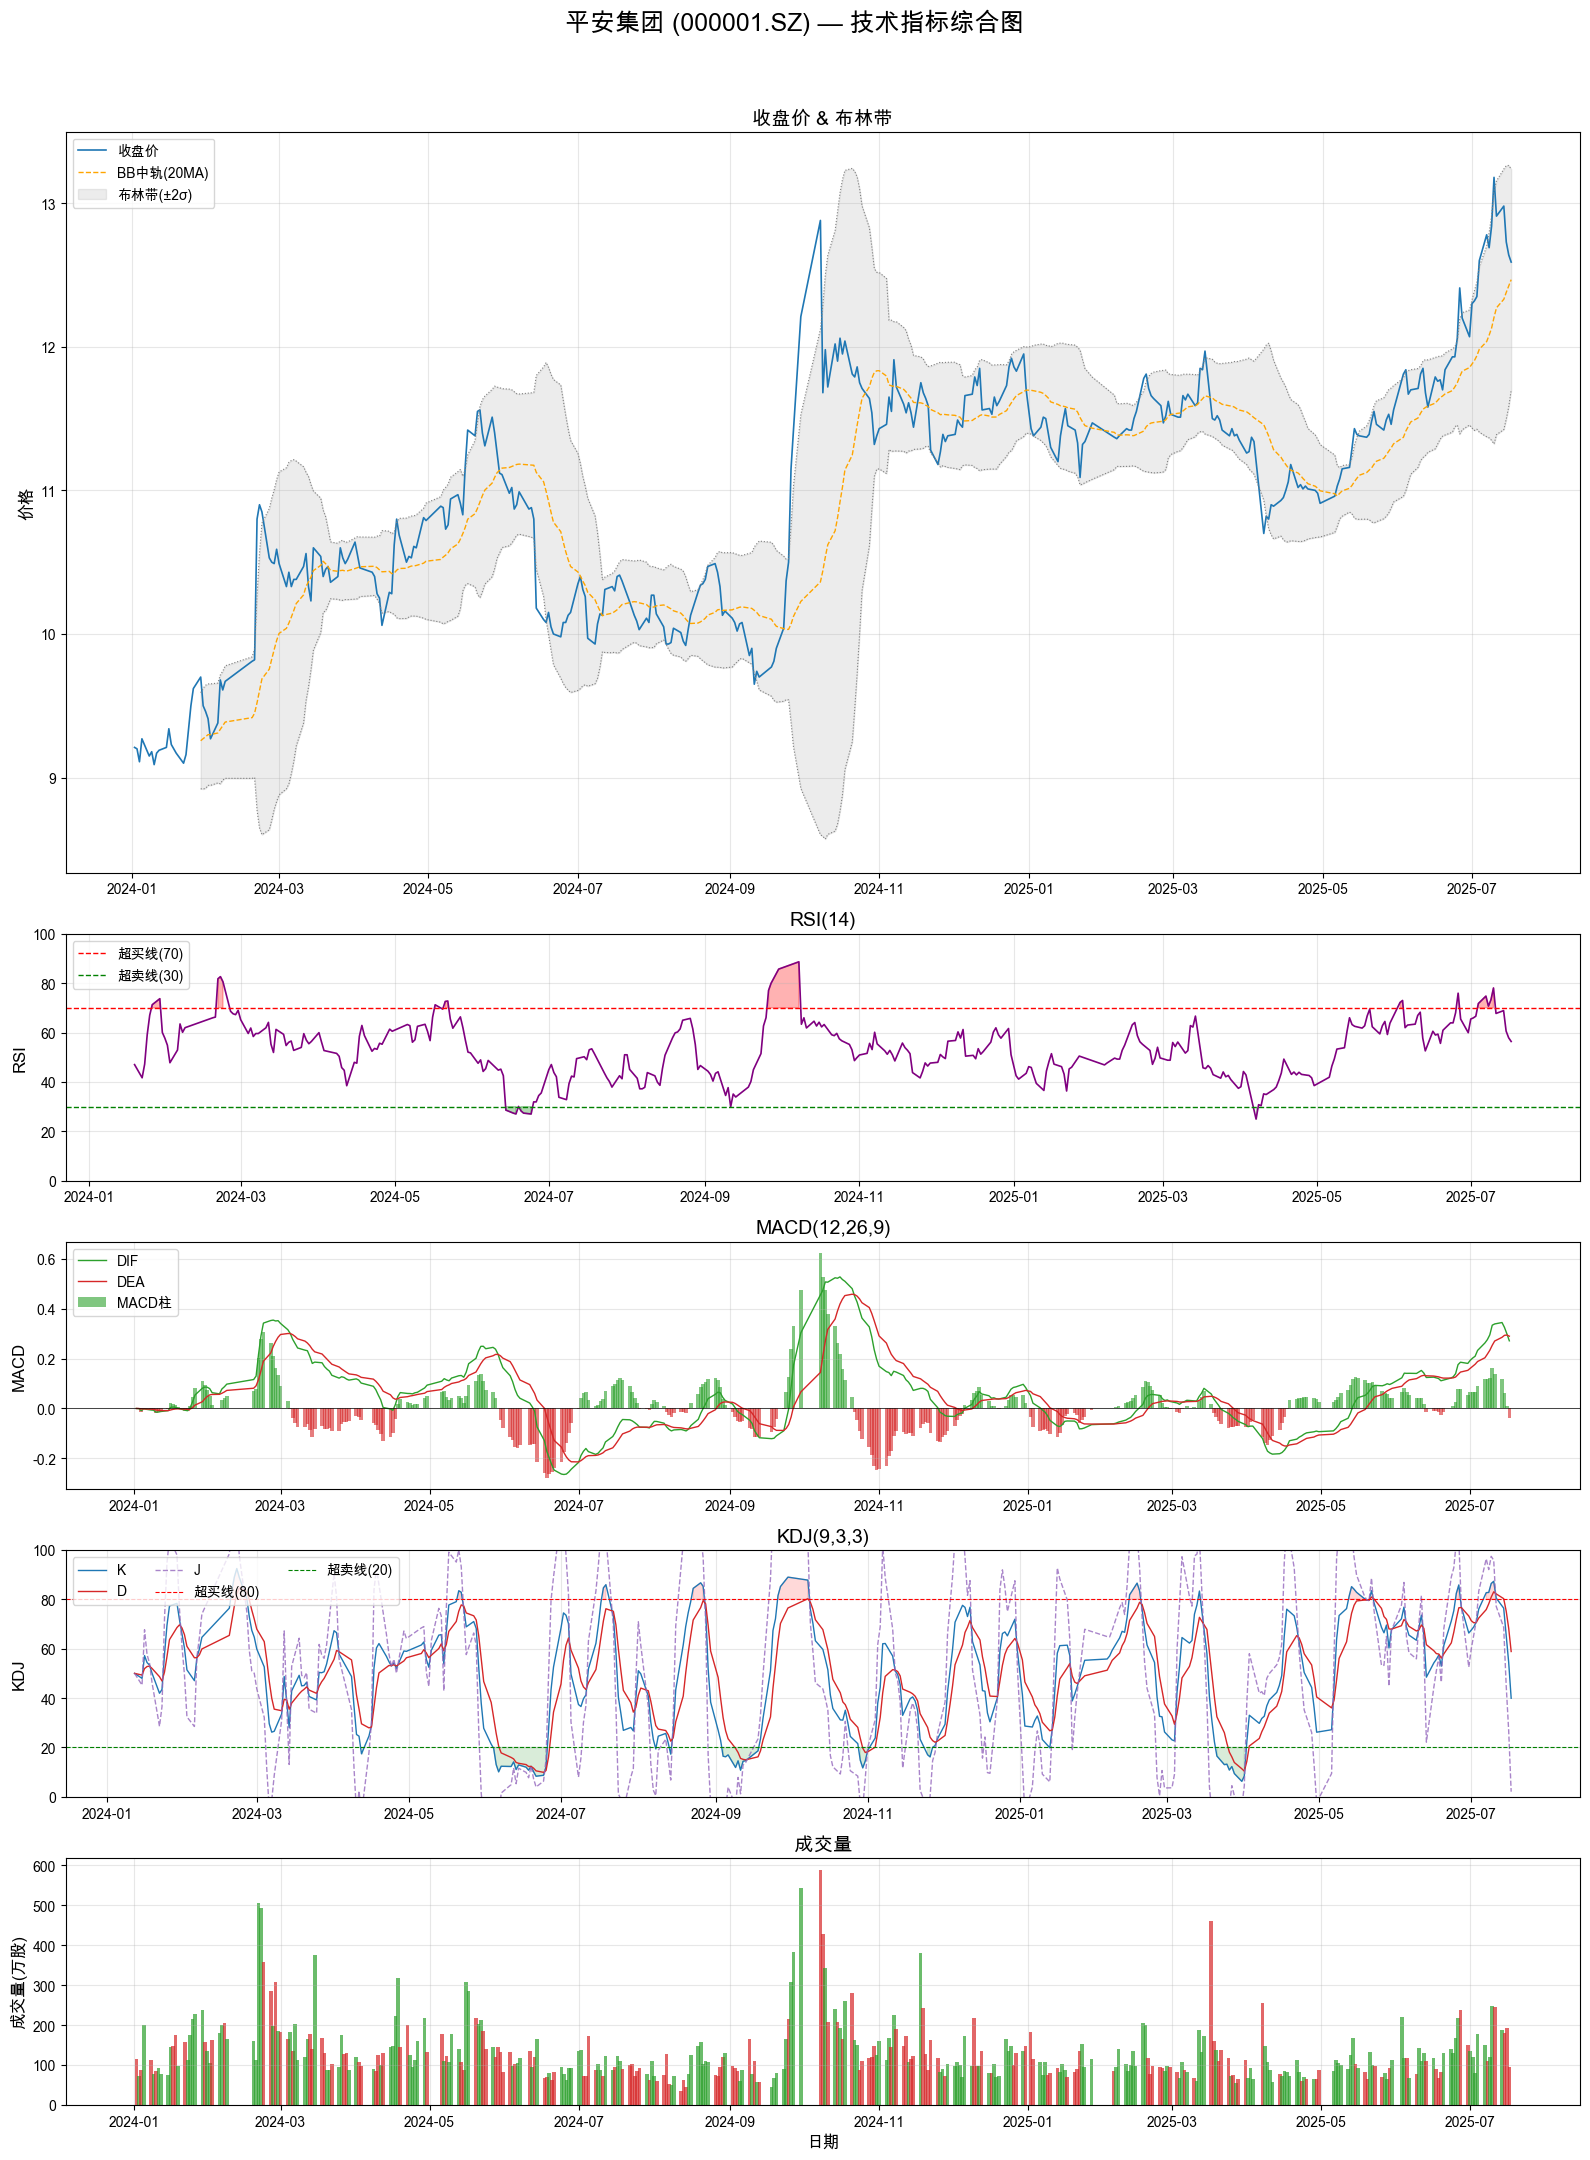

In [17]:
# 绘制平安集团
plot_stock_indicators(df_pingan, '平安集团 (000001.SZ) — 技术指标综合图')

## 8. 指标汇总表（最新5个交易日）

In [ ]:
cols = ['trade_date','close','RSI_14','MACD_DIF','MACD_DEA','MACD_HIST',
        'BB_MID','BB_UPPER','BB_LOWER','KDJ_K','KDJ_D','KDJ_J']

print('=== 三一重工 最新5日指标 ===')
print(df_sany[cols].tail(5).to_string(index=False))

print('\n=== 平安集团 最新5日指标 ===')
print(df_pingan[cols].tail(5).to_string(index=False))

---
**指标说明**：
- **RSI(14)**：>70 视为超买区域（红色），<30 视为超卖区域（绿色）
- **MACD(12,26,9)**：DIF上穿DEA为金叉（看多），DIF下穿DEA为死叉（看空）
- **布林带(20,2)**：股价触及上轨可能回调，触及下轨可能反弹；带宽收缩预示即将变盘
- **KDJ(9,3,3)**：K > 80 超买（红色），K < 20 超卖（绿色）；K 上穿 D 为金叉（看多），下穿为死叉（看空）；J 值波动最大，可提前反映拐点